In [ ]:
# Customer Churn Prediction
# Author: Prasitha

# Objective:
# Predict whether a customer is likely to leave the company.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telco.csv (1).zip to telco.csv (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('telco.csv (1).zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import os

os.listdir()

['.config', 'telco.csv', 'telco.csv (1).zip', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("telco.csv")

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.shape

(7043, 50)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
os.listdir()

['.config', 'telco.csv', 'telco.csv (1).zip', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("telco.csv")

In [ ]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.shape

(7043, 50)

In [ ]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [ ]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
df["Churn Label"].value_counts(normalize=True)*100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


In [ ]:
df.drop(
    [
        "Customer Status",
        "Churn Score",
        "Churn Category",
        "Churn Reason"
    ],
    axis=1,
    inplace=True
)

In [ ]:
df.drop(
    "Customer ID",
    axis=1,
    inplace=True
)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Offer,3877
Internet Type,1526
Under 30,0
Age,0
Gender,0
Dependents,0
Number of Dependents,0
Country,0
State,0
City,0


In [ ]:
df["Internet Service"].value_counts()

,count
Internet Service,
Yes,5517
No,1526


In [ ]:
df[df["Internet Type"].isnull()][["Internet Service","Internet Type"]].head()

,Internet Service,Internet Type
25,No,NaN
41,No,NaN
199,No,NaN
373,No,NaN
375,No,NaN


In [ ]:
df["Internet Type"] = df["Internet Type"].fillna("No Internet")

In [ ]:
df["Offer"] = df["Offer"].fillna("No Offer")

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
df["Churn Label"].value_counts(normalize=True)*100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


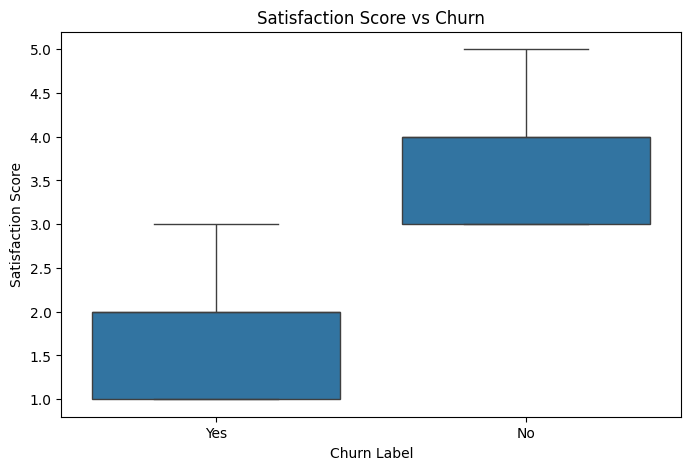

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Satisfaction Score",
    data=df
)

plt.title("Satisfaction Score vs Churn")
plt.show()

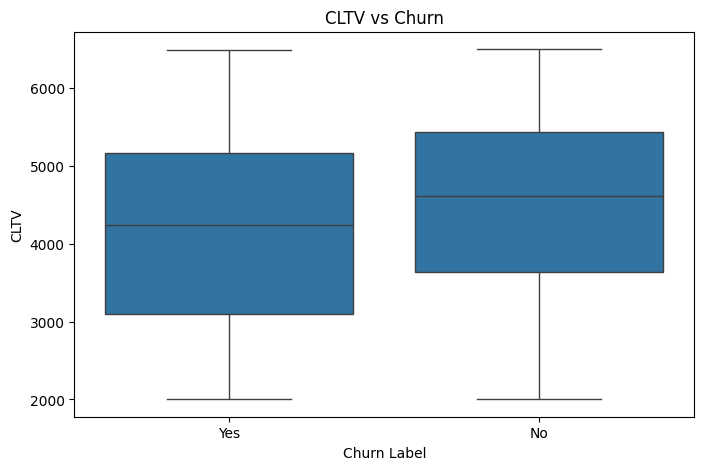

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="CLTV",
    data=df
)

plt.title("CLTV vs Churn")
plt.show()

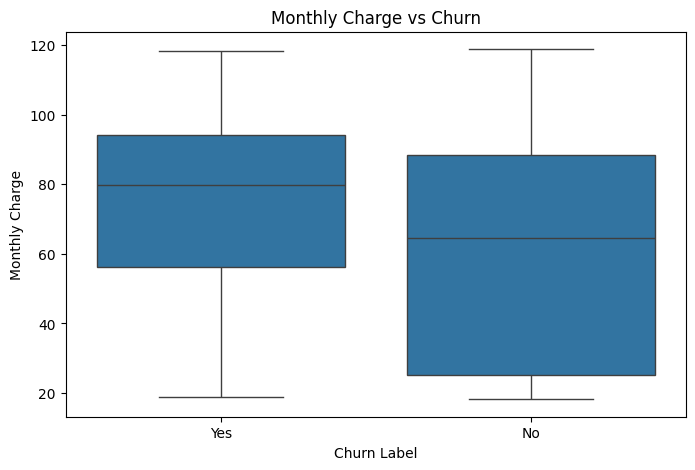

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Monthly Charge",
    data=df
)

plt.title("Monthly Charge vs Churn")
plt.show()

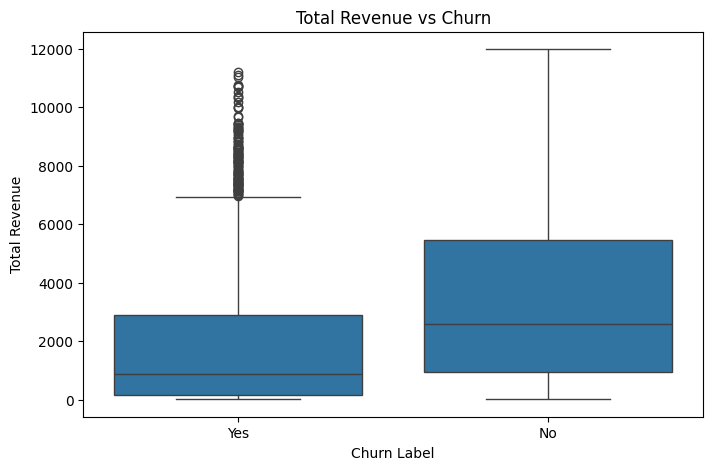

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Total Revenue",
    data=df
)

plt.title("Total Revenue vs Churn")
plt.show()

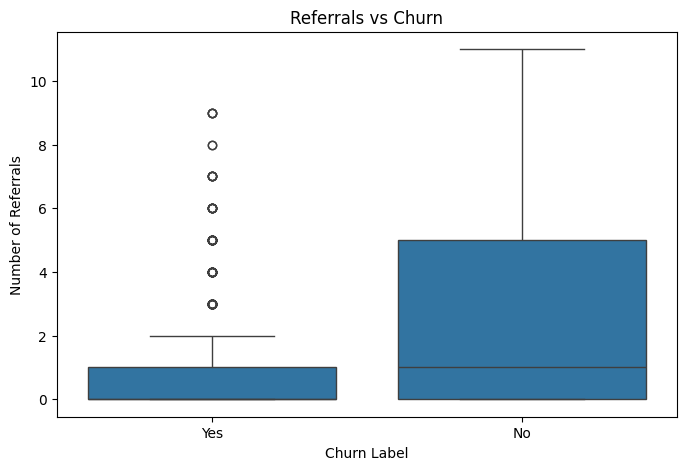

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Number of Referrals",
    data=df
)

plt.title("Referrals vs Churn")
plt.show()

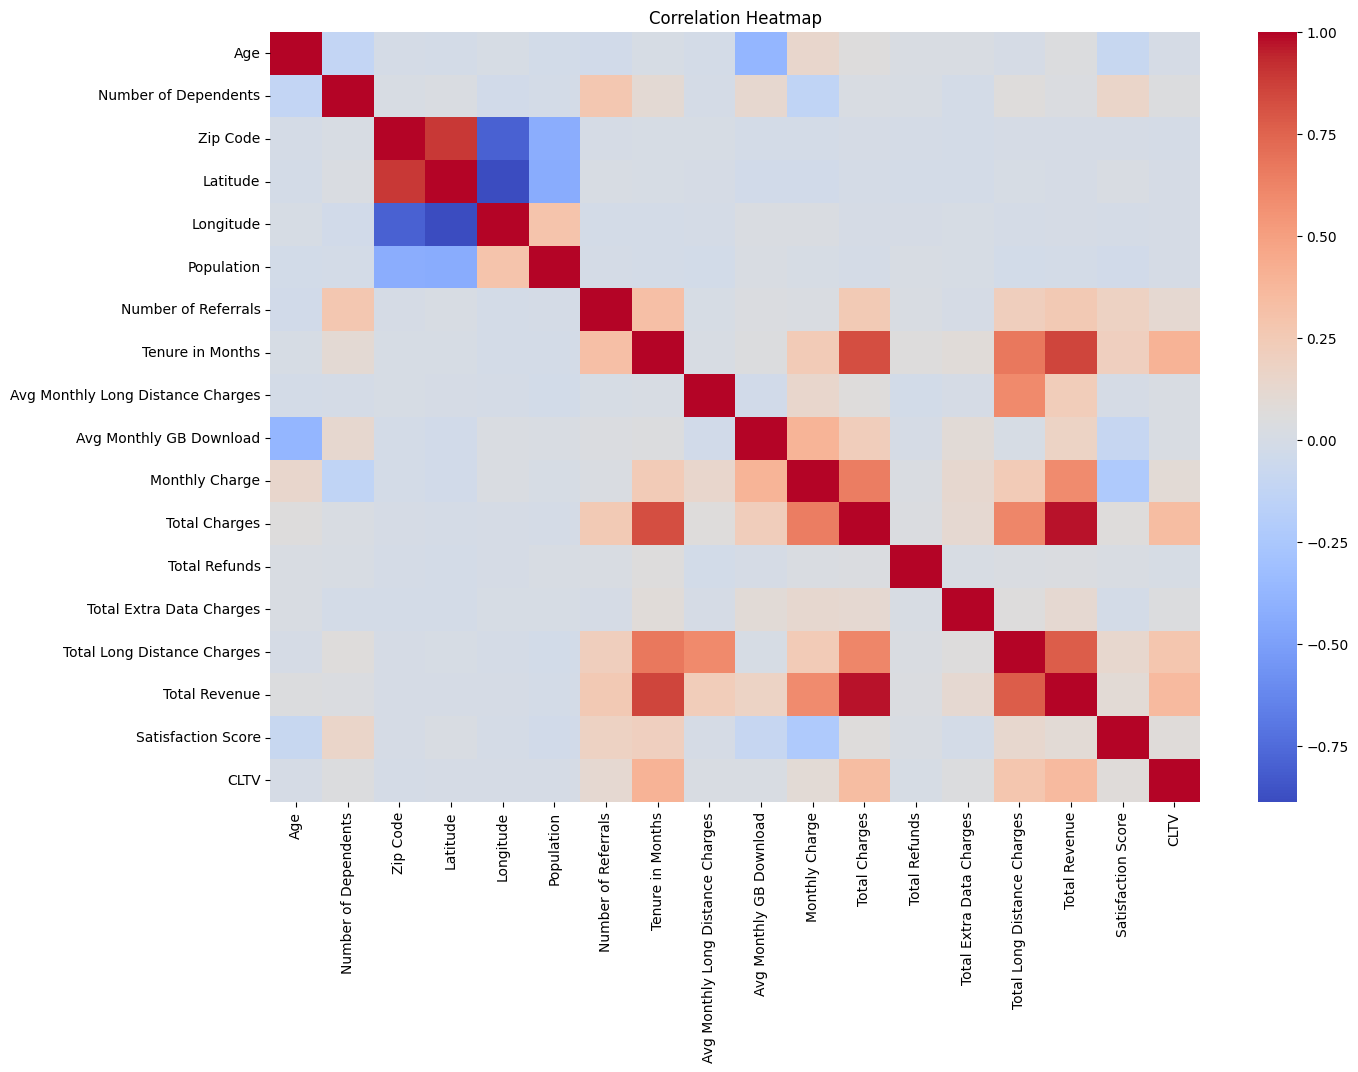

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

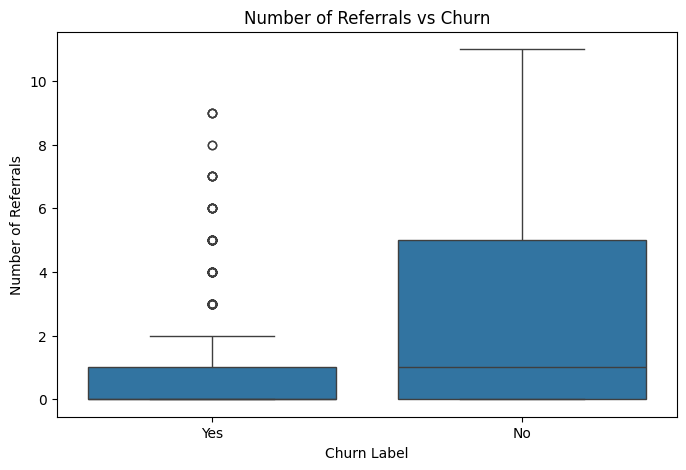

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Number of Referrals",
    data=df
)

plt.title("Number of Referrals vs Churn")
plt.show()

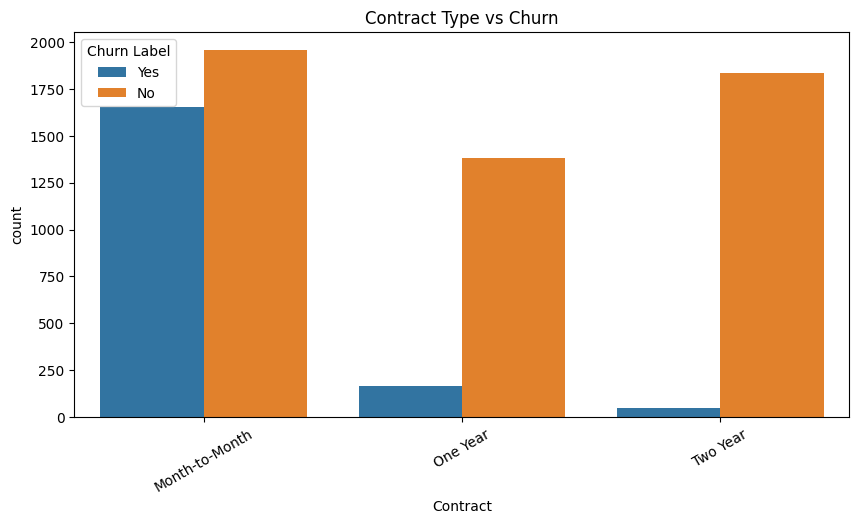

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Contract",
    hue="Churn Label",
    data=df
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.show()

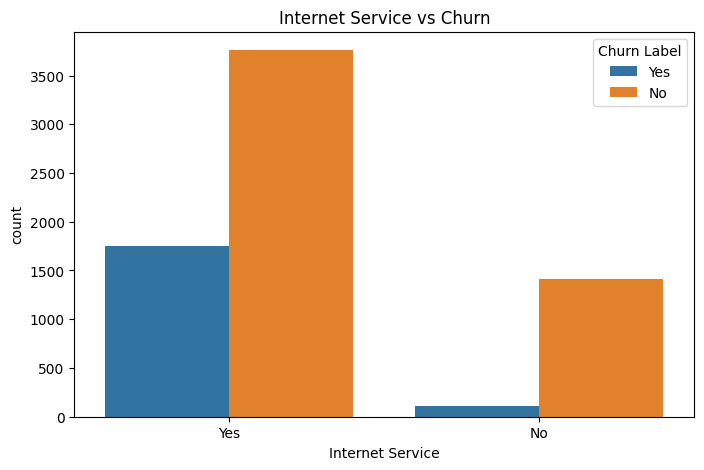

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Internet Service",
    hue="Churn Label",
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

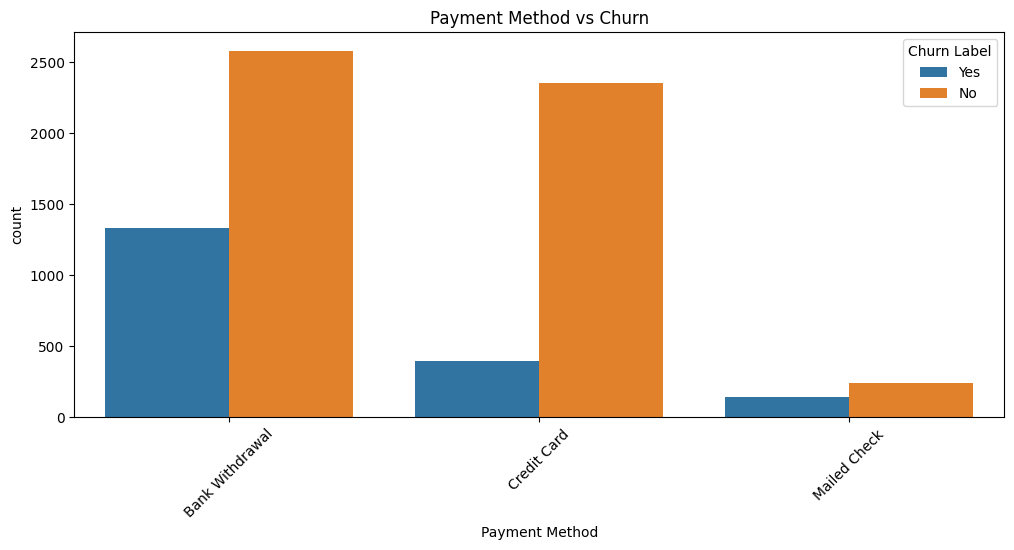

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="Payment Method",
    hue="Churn Label",
    data=df
)

plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_ml = df.copy()

df_ml = df_ml.drop(
    columns=[
        'Churn Label'
    ]
)

In [ ]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Country', 'State', 'City', 'Quarter', 'Referred a Friend', 'Offer',
       'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Churn Label'],
      dtype='object')

In [ ]:
X = df.drop("Churn Label", axis=1)

In [ ]:
y = df["Churn Label"]

In [ ]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [ ]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Country', 'State', 'City', 'Quarter', 'Referred a Friend', 'Offer',
       'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Churn Label'],
      dtype='object')

In [ ]:
df_ml.columns

Index(['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Country', 'State', 'City', 'Zip Code',
       'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend',
       'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'CLTV'],
      dtype='object')

In [ ]:
y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [ ]:
X = df_ml

In [ ]:
df_ml = df.copy()

In [ ]:
df_ml.drop(
    columns=[
        'Country',
        'State',
        'City'
    ],
    inplace=True
)

In [ ]:
y = df_ml["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [ ]:
X = df_ml.drop("Churn Label", axis=1)

In [ ]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
X.shape

(7043, 48)

In [ ]:
df_ml.columns

Index(['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude',
       'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Label', 'CLTV'],
      dtype='object')

In [ ]:
y = df_ml["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

In [ ]:
y.head()

,Churn Label
0,1
1,1
2,1
3,1
4,1


In [ ]:
X = df_ml.drop("Churn Label", axis=1)

In [ ]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
X.shape

(7043, 48)

In [ ]:
X.head()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,...,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,78,0,90022,34.023810,-118.156582,68701,0,1,0.00,8,...,False,False,True,False,False,False,False,True,False,False
1,74,1,90063,34.044271,-118.185237,55668,1,8,48.85,17,...,False,False,False,False,True,False,False,True,True,False
2,71,3,90065,34.108833,-118.229715,47534,0,18,11.33,52,...,False,True,True,True,True,False,False,True,False,False
3,78,1,90303,33.936291,-118.332639,27778,1,25,19.76,12,...,False,True,True,False,True,False,False,True,False,False
4,80,1,90602,33.972119,-118.020188,26265,1,37,6.33,14,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
y_train.value_counts()

,count
Churn Label,
0,4139
1,1495


In [ ]:
y_train_smote.value_counts()

,count
Churn Label,
0,4139
1,4139


In [ ]:
X.shape

(7043, 48)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_smote,
    y_train_smote
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.7636621717530163
Precision: 0.5377532228360957
Recall   : 0.7807486631016043
F1 Score : 0.6368593238822247


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf = rf.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9517388218594748
Precision: 0.9664634146341463
Recall   : 0.8475935828877005
F1 Score : 0.9031339031339032


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

Accuracy : 0.9652235628105039
Precision: 0.968299711815562
Recall   : 0.8983957219251337
F1 Score : 0.9320388349514563


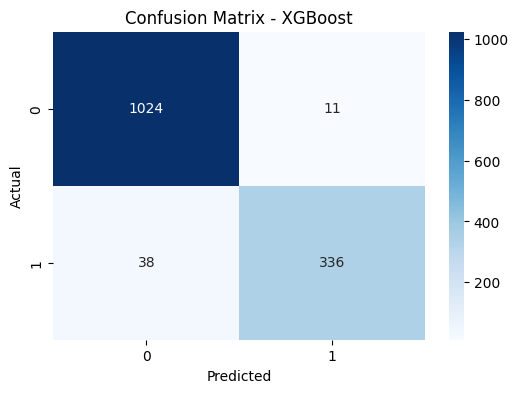

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9909116742876333


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
16,Satisfaction Score,0.658882
31,Internet Service_Yes,0.065772
35,Online Security_Yes,0.039337
33,Internet Type_Fiber Optic,0.038572
6,Number of Referrals,0.020786
7,Tenure in Months,0.015149
1,Number of Dependents,0.012777
45,Paperless Billing_Yes,0.012765
44,Contract_Two Year,0.010869
28,Offer_Offer E,0.007916


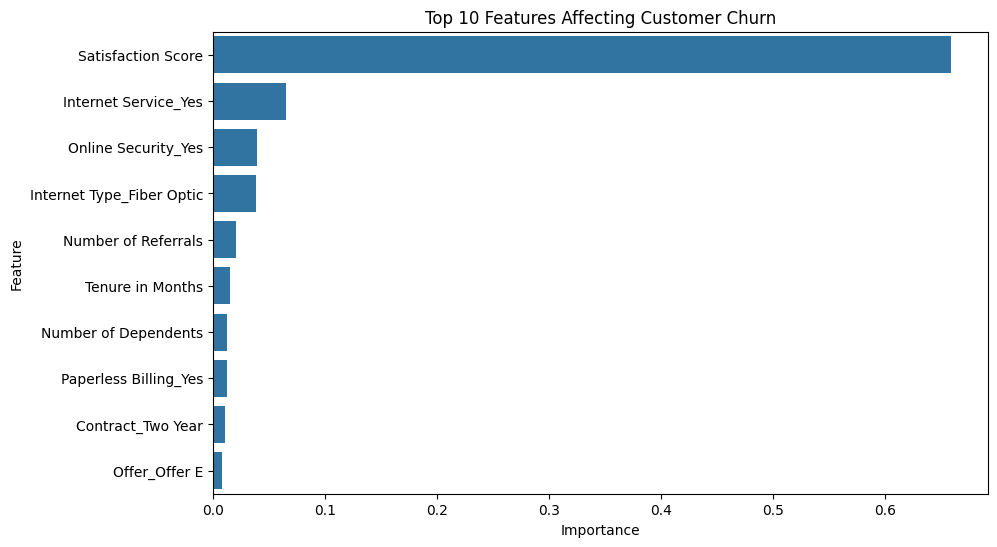

In [ ]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features Affecting Customer Churn")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
16,Satisfaction Score,0.658882
31,Internet Service_Yes,0.065772
35,Online Security_Yes,0.039337
33,Internet Type_Fiber Optic,0.038572
6,Number of Referrals,0.020786
7,Tenure in Months,0.015149
1,Number of Dependents,0.012777
45,Paperless Billing_Yes,0.012765
44,Contract_Two Year,0.010869
28,Offer_Offer E,0.007916


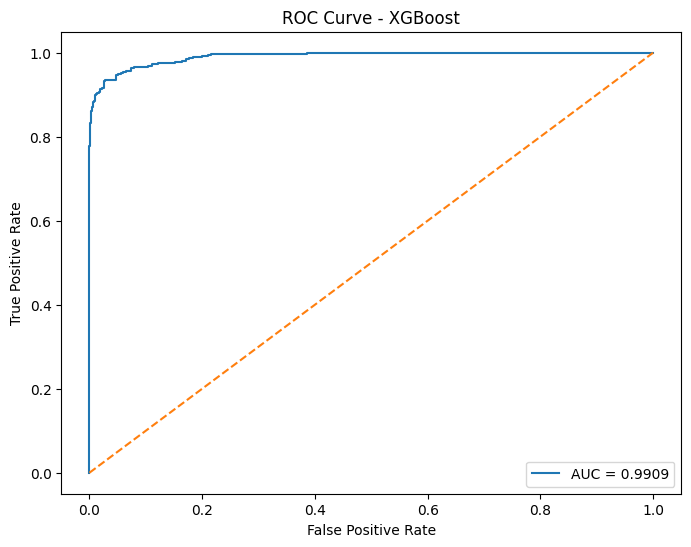

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_score:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

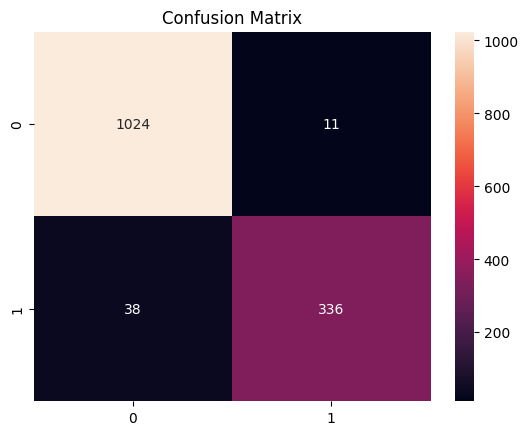

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
sample_customer = X_test.iloc[[0]]

prediction = xgb.predict(sample_customer)

print(prediction)

[0]


In [ ]:
sample_customer = X_test.iloc[[0]]

prediction = xgb.predict(sample_customer)

if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

Customer is likely to stay


In [ ]:
sample_customer = X_test.iloc[[0]]

probability = xgb.predict_proba(sample_customer)

print(probability)

[[9.999051e-01 9.489435e-05]]


In [ ]:
churn_prob = probability[0][1] * 100

print(f"Churn Probability: {churn_prob:.2f}%")

Churn Probability: 0.01%


In [ ]:
def predict_churn(customer_data):

    prediction = xgb.predict(customer_data)
    probability = xgb.predict_proba(customer_data)[0][1] * 100

    if prediction[0] == 1:
        print(f"Customer likely to churn ({probability:.2f}%)")
    else:
        print(f"Customer likely to stay ({100-probability:.2f}%)")

In [ ]:
predict_churn(X_test.iloc[[0]])

Customer likely to stay (99.99%)


In [ ]:
sample_customer = X_test.iloc[[0]]

prediction = xgb.predict(sample_customer)

probability = xgb.predict_proba(sample_customer)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[9.999051e-01 9.489435e-05]]


In [ ]:
import pickle

pickle.dump(
    xgb,
    open("churn_model.pkl", "wb")
)

In [ ]:
import pickle

pickle.dump(
    X.columns,
    open("model_columns.pkl", "wb")
)

In [ ]:
from google.colab import files

files.download("churn_model.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
16,Satisfaction Score,0.658882
31,Internet Service_Yes,0.065772
35,Online Security_Yes,0.039337
33,Internet Type_Fiber Optic,0.038572
6,Number of Referrals,0.020786
7,Tenure in Months,0.015149
1,Number of Dependents,0.012777
45,Paperless Billing_Yes,0.012765
44,Contract_Two Year,0.010869
28,Offer_Offer E,0.007916


In [ ]:
df.to_csv("customer_churn_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("customer_churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>